# LIBRARIES

In [1]:
import os
import cv2
import numpy as np
import pickle
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

# CONFIGURATIONS

In [2]:
PATH_TILDA = Path('/kaggle/input/datasets/angelolmg/tilda-400/masks')
PATH_HKU = Path('/kaggle/input/datasets/angelogoes/hku-dataset')
CACHE_PATH = '/kaggle/working/metadata_cache.pkl'
PATCH_SIZES = [32, 64, 128]
GRID_VALUES = [i / 100.0 for i in range(0, 101)]
SHOW_ANNOTATIONS = True  # Mostra setas e caixas
DYNAMIC_RANGE = True     # Se True, cada mapa usa seu próprio min/max para máximo contraste
GLOBAL_VMIN, GLOBAL_VMAX = 0.1, 0.3  # Só usado se DYNAMIC_RANGE = False

# UTILITIES

In [3]:
def get_patch_counts(mask_binary, p_size):
    """Fatia a máscara em grids e conta pixels brancos por patch de forma vetorizada."""
    H, W = mask_binary.shape
    
    # Trunca a imagem para caber exato no tamanho do patch (descarta bordas marginais)
    H_trunc = (H // p_size) * p_size
    W_trunc = (W // p_size) * p_size
    mask_trunc = mask_binary[:H_trunc, :W_trunc]
    
    # Reshape mágico do NumPy para criar blocos (patches) sem loops
    # De (H, W) para (num_patches_H, p_size, num_patches_W, p_size)
    patches = mask_trunc.reshape(H_trunc // p_size, p_size, W_trunc // p_size, p_size)
    
    # Soma nos eixos do patch (eixo 1 e 3)
    counts = patches.sum(axis=(1, 3))
    
    # Retorna como um array 1D
    return counts.flatten()

def process_dataset(mask_files, name):
    print(f"Processando {len(mask_files)} imagens do dataset {name}...")
    dataset_data = []
    
    for f in mask_files:
        # Carrega a imagem em tons de cinza
        mask = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
        if mask is None: continue
            
        # Binariza para garantir que defeito=1 e fundo=0 (ajuste se suas mascaras forem 255)
        mask_bin = (mask > 0).astype(np.uint32)
        total_area = mask_bin.sum()
        
        # Ignora imagens totalmente sem defeito para o cálculo do IoU Max
        if total_area == 0:
            continue
            
        img_info = {
            'id': os.path.basename(f),
            'total_area': total_area,
            'patch_counts': {}
        }
        
        for p in PATCH_SIZES:
            img_info['patch_counts'][str(p)] = get_patch_counts(mask_bin, p)
            
        dataset_data.append(img_info)
        
    print(f"[{name}] {len(dataset_data)} imagens com defeito processadas.")
    return dataset_data

def plot_custom_heatmap(ax, data, title):
    # Lógica Dinâmica: Se ativado, vmin/vmax são calculados na hora para este dataset
    local_vmin = np.min(data) if DYNAMIC_RANGE else GLOBAL_VMIN
    local_vmax = np.max(data) if DYNAMIC_RANGE else GLOBAL_VMAX

    # =========================================================================
    # NOVA LÓGICA AUTOMÁTICA DE TICKS
    # =========================================================================
    tick_positions = []
    tick_labels = []
    for idx, val in enumerate(GRID_VALUES):
        if np.isclose(val * 10, np.round(val * 10)):
            tick_positions.append(idx + 0.5) # O +0.5 centraliza no bloco
            tick_labels.append(f"{val:.1f}")
    
    # Heatmap sem passar x/yticklabels diretamente para o Seaborn
    sns.heatmap(data, ax=ax, annot=False, cmap="viridis", 
                vmin=local_vmin, vmax=local_vmax)
    
    # Travando os ticks nas coordenadas exatas para remover os tracinhos vazios
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels)
    
    # Aplicamos a configuração do tick da barra lateral da forma correta:
    ax.collections[0].colorbar.ax.tick_params(labelsize=14)
    
    # Modo Cartesiano: (0,0) no canto inferior esquerdo
    ax.invert_yaxis()
    
    # Títulos e labels limpos e sem o símbolo de %
    ax.set_title(title, fontsize=18, pad=10)
    ax.set_xlabel(r'$\beta$ (Patch Area %)', fontsize=16)
    ax.set_ylabel(r'$\alpha$ (Total Defect Area %)', fontsize=16)
    
    # Ticks maiores, eixo Y na horizontal (rotation=0) e X em 45 graus
    ax.tick_params(axis='x', labelsize=14, rotation=45)
    ax.tick_params(axis='y', labelsize=14, rotation=0)

    if SHOW_ANNOTATIONS:
        idx = np.unravel_index(np.argmax(data), data.shape)
        val_alpha = GRID_VALUES[idx[0]]
        val_beta = GRID_VALUES[idx[1]]
        max_val = data[idx]

        # Quadrado vermelho destacando a célula
        rect = plt.Rectangle((idx[1], idx[0]), 1, 1, fill=False, edgecolor='red', lw=3)
        ax.add_patch(rect)

        # O 'fr' no início avisa o Python que é uma f-string E uma raw-string ao mesmo tempo,
        # impedindo que o '\b' de \beta seja interpretado como um comando de "backspace"
        text_str = fr"$\alpha$: {val_alpha:.2f}, $\beta$: {val_beta:.2f}" + f"\nIoU: {max_val:.3f}"
        
        ax.text(0.95, 0.95, text_str, 
                transform=ax.transAxes, 
                ha='right', va='top', 
                color='black', 
                fontsize=16, 
                bbox=dict(boxstyle="square,pad=0.5", fc="white", ec="red", alpha=0.9, lw=2))

# EXTRACT PATCH METADATA AND CACHE

In [4]:
if os.path.exists(CACHE_PATH):
    print(f"✅ Cache encontrado! Carregando {CACHE_PATH}...")
    with open(CACHE_PATH, 'rb') as f:
        metadata = pickle.load(f)
    print("Dados carregados com sucesso. Pronto para o Grid Search.")
    
else:
    print("❌ Cache não encontrado. Iniciando mapeamento de diretórios...")
    
    # Mapeamento
    tilda_mask_paths = list(PATH_TILDA.glob('*.png'))
    hku_mask_paths = list(PATH_HKU.rglob('groundT_*.bmp'))

    print(f"TILDA: {len(tilda_mask_paths)} máscaras encontradas.")
    print(f"HKU: {len(hku_mask_paths)} máscaras encontradas.")
    
    if not tilda_mask_paths and not hku_mask_paths:
        raise FileNotFoundError("Erro crítico: Arquivo de cache ausente e pastas de imagens não encontradas!")

    # Processamento
    metadata = {
        'TILDA': process_dataset(tilda_mask_paths, 'TILDA'),
        'HKU': process_dataset(hku_mask_paths, 'HKU')
    }
    
    # Salva o Cache
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(metadata, f)
    print(f"✅ Processamento concluído e cache salvo em {CACHE_PATH}!")

❌ Cache não encontrado. Iniciando mapeamento de diretórios...
TILDA: 400 máscaras encontradas.
HKU: 81 máscaras encontradas.
Processando 400 imagens do dataset TILDA...
[TILDA] 400 imagens com defeito processadas.
Processando 81 imagens do dataset HKU...
[HKU] 81 imagens com defeito processadas.
✅ Processamento concluído e cache salvo em /kaggle/working/metadata_cache.pkl!


# GRID SEARCH IoU_max (ABLATION)

In [5]:
results = {}

# Cálculo do total de passos para uma barra informativa (opcional)
for dataset_name, images in metadata.items():
    results[dataset_name] = {}
    
    for p_size in PATCH_SIZES:
        matrix = np.zeros((len(GRID_VALUES), len(GRID_VALUES)))
        patch_area = p_size * p_size
        
        # Adicionamos o tqdm aqui no loop das imagens
        # O desc (description) ajuda a saber exatamente onde o processamento está
        print(f"\nCalculando Grid: {dataset_name} | Patch Size: {p_size}")
        for img in tqdm(images, desc=f"Processando {dataset_name} ({p_size}x{p_size})"):
            total_area = img['total_area']
            counts = img['patch_counts'][str(p_size)]
            
            for i, alpha in enumerate(GRID_VALUES):
                # Otimização: pré-calculamos o threshold de alpha para a imagem
                thresh_alpha = alpha * total_area
                
                for j, beta in enumerate(GRID_VALUES):
                    # Otimização: pré-calculamos o threshold de beta para o patch
                    thresh_beta = beta * patch_area
                    
                    # LÓGICA VETORIZADA
                    is_defective = (counts >= thresh_alpha) | (counts >= thresh_beta)
                    
                    tp = np.sum(counts[is_defective])
                    fp = np.sum(patch_area - counts[is_defective])
                    
                    denom = total_area + fp
                    iou = (tp / denom) if denom > 0 else 0.0
                    
                    matrix[i, j] += iou
                    
        # Tira a média dividindo pelo número de imagens
        matrix_mean = matrix / len(images)
        results[dataset_name][str(p_size)] = matrix_mean

print("\nGrid Search concluído! Matrizes geradas com sucesso.")


Calculando Grid: TILDA | Patch Size: 32


Processando TILDA (32x32):   0%|          | 0/400 [00:00<?, ?it/s]


Calculando Grid: TILDA | Patch Size: 64


Processando TILDA (64x64):   0%|          | 0/400 [00:00<?, ?it/s]


Calculando Grid: TILDA | Patch Size: 128


...


Calculando Grid: HKU | Patch Size: 64


Processando HKU (64x64):   0%|          | 0/81 [00:00<?, ?it/s]


Calculando Grid: HKU | Patch Size: 128


Processando HKU (128x128):   0%|          | 0/81 [00:00<?, ?it/s]


Grid Search concluído! Matrizes geradas com sucesso.


# VISUALIZATIONS

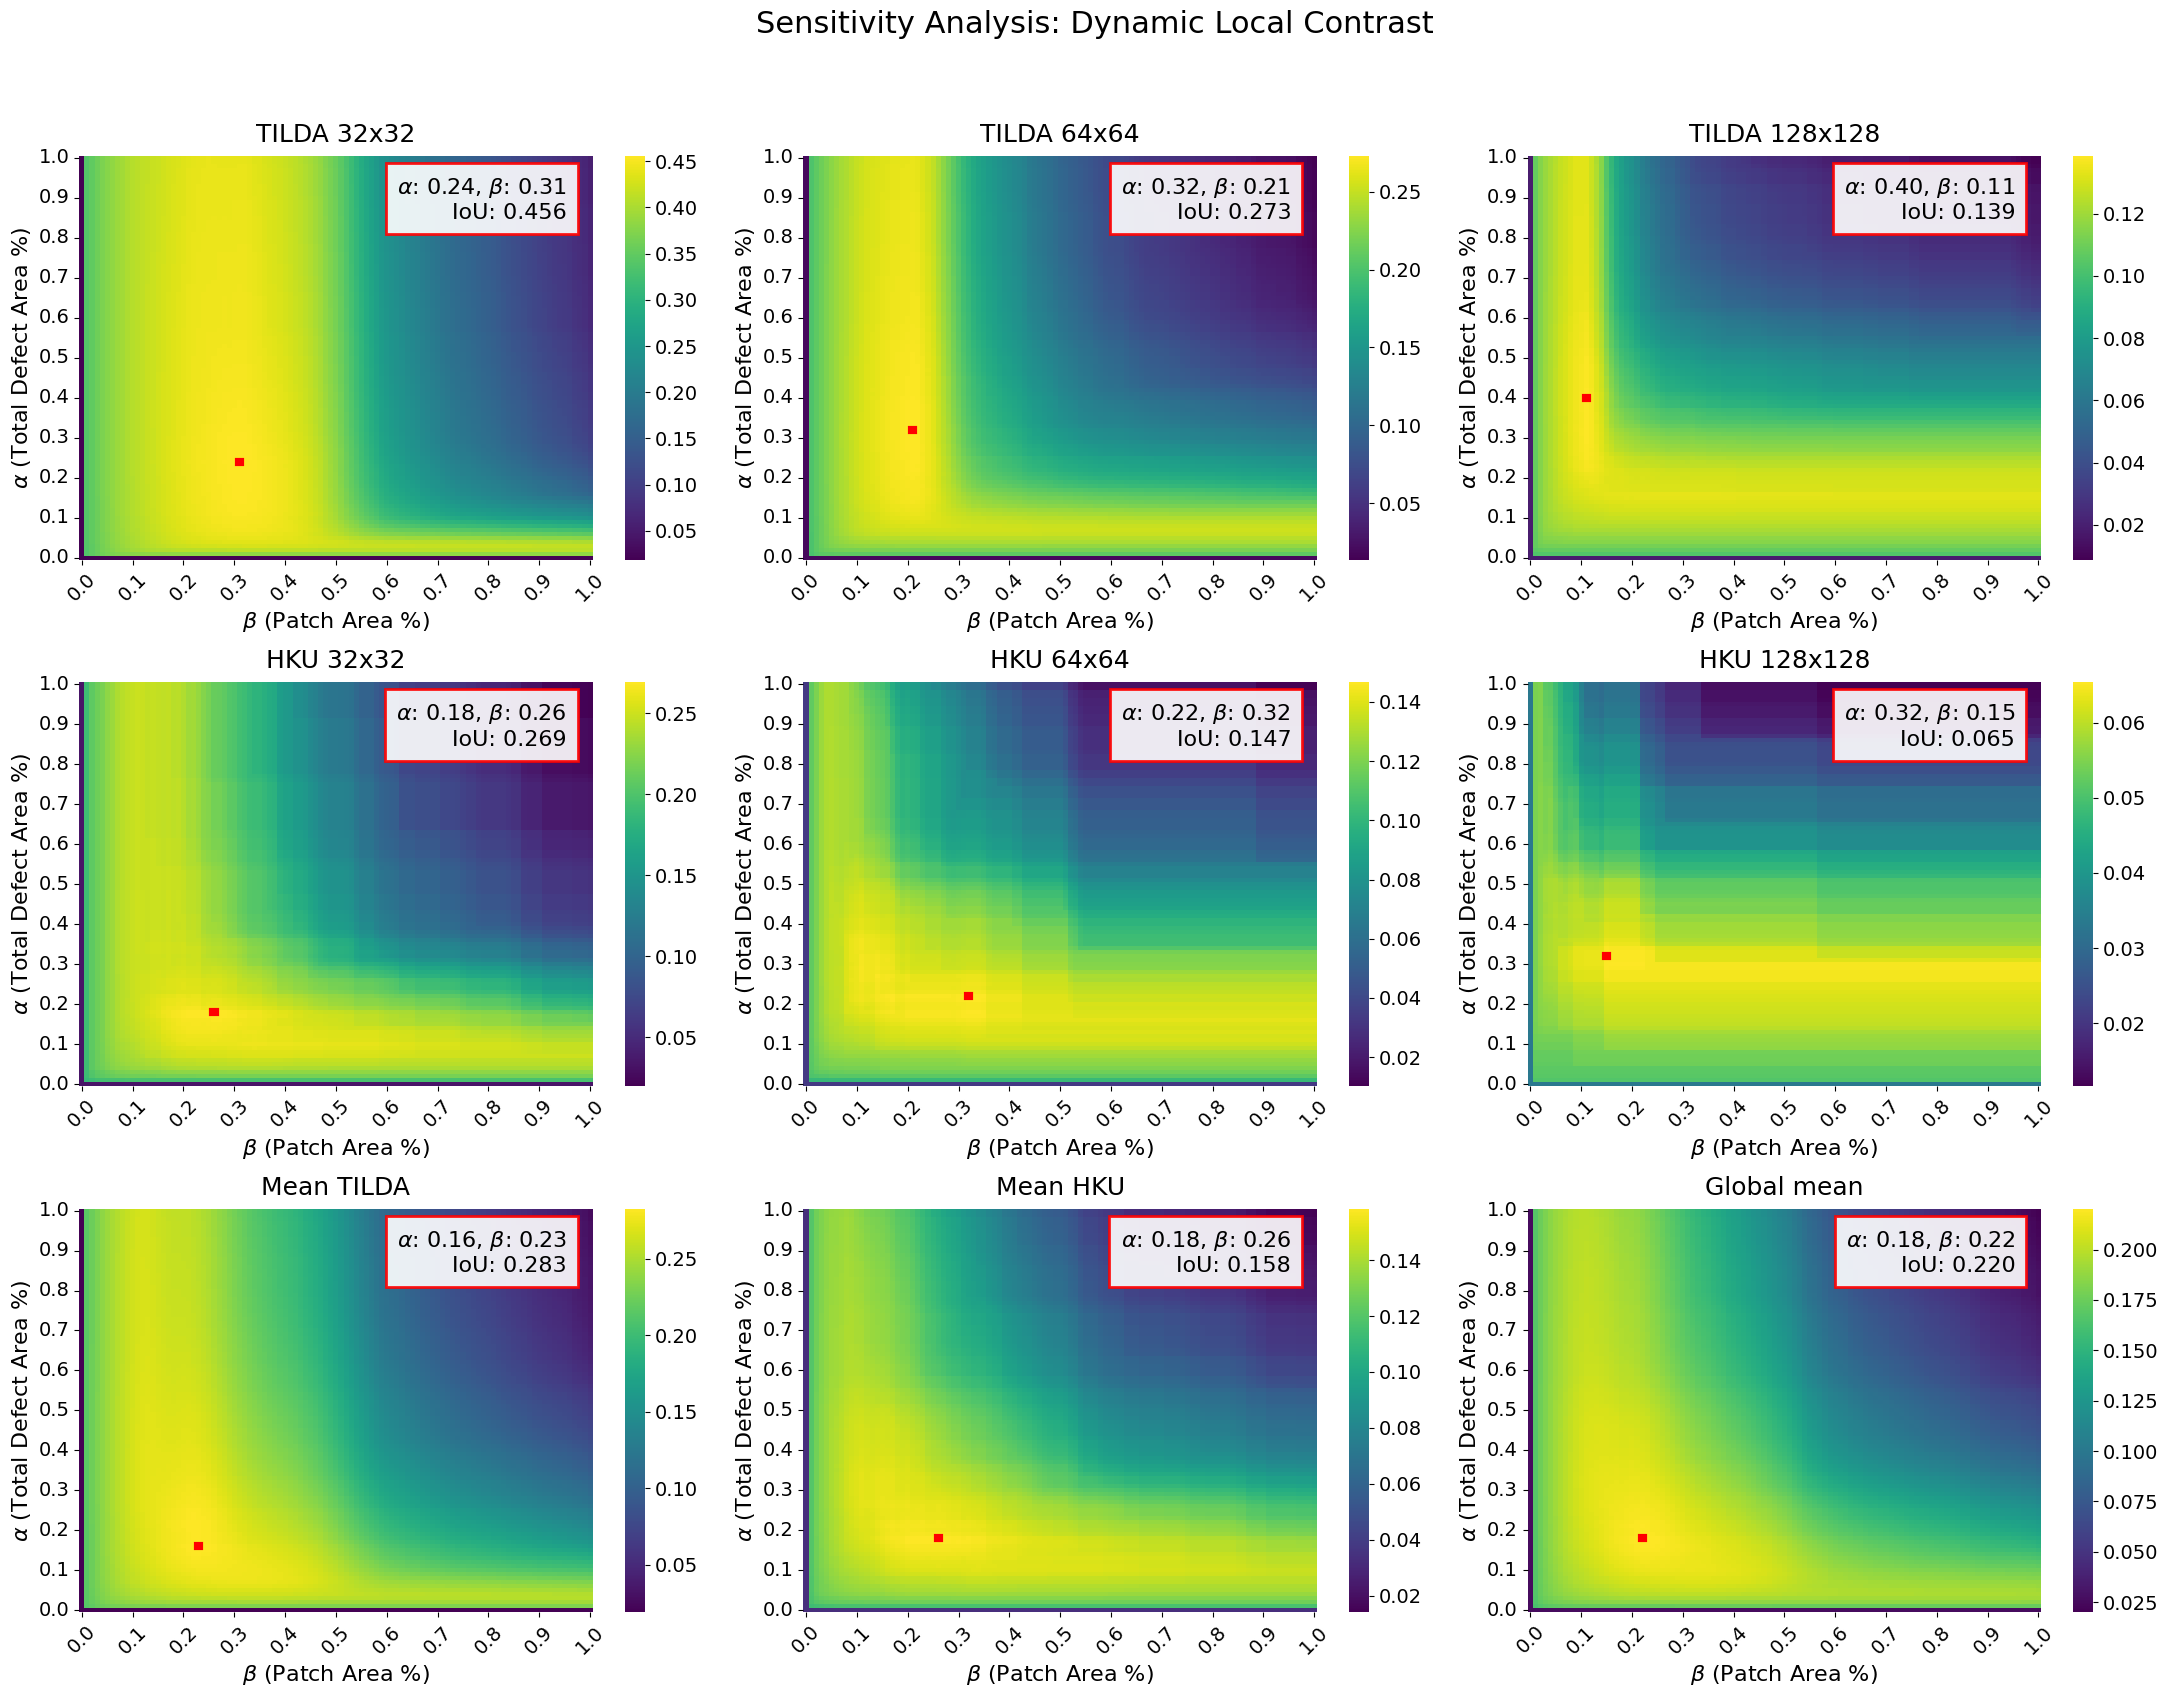

In [6]:
t32, t64, t128 = [results['TILDA'][str(p)] for p in PATCH_SIZES]
h32, h64, h128 = [results['HKU'][str(p)] for p in PATCH_SIZES]

mean_tilda = np.mean([t32, t64, t128], axis=0)
mean_hku = np.mean([h32, h64, h128], axis=0)
global_matrix = np.mean([t32, t64, t128, h32, h64, h128], axis=0)

plot_list = [
    [t32, 'TILDA 32x32'], [t64, 'TILDA 64x64'], [t128, 'TILDA 128x128'],
    [h32, 'HKU 32x32'],   [h64, 'HKU 64x64'],   [h128, 'HKU 128x128'],
    [mean_tilda, 'Mean TILDA'], [mean_hku, 'Mean HKU'], [global_matrix, 'Global mean']
]

SHOW_ANNOTATIONS = True

# 3. Execução do Plot 3x3
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
mode_str = "Dynamic Local Contrast" if DYNAMIC_RANGE else "Global Static Contrast"
fig.suptitle(f'Sensitivity Analysis: {mode_str}', fontsize=22, y=0.97)

for idx, (data, title) in enumerate(plot_list):
    row, col = idx // 3, idx % 3
    plot_custom_heatmap(axes[row, col], data, title)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.savefig('/kaggle/working/sensitivity_grid_dynamic.png', dpi=300)
plt.show()

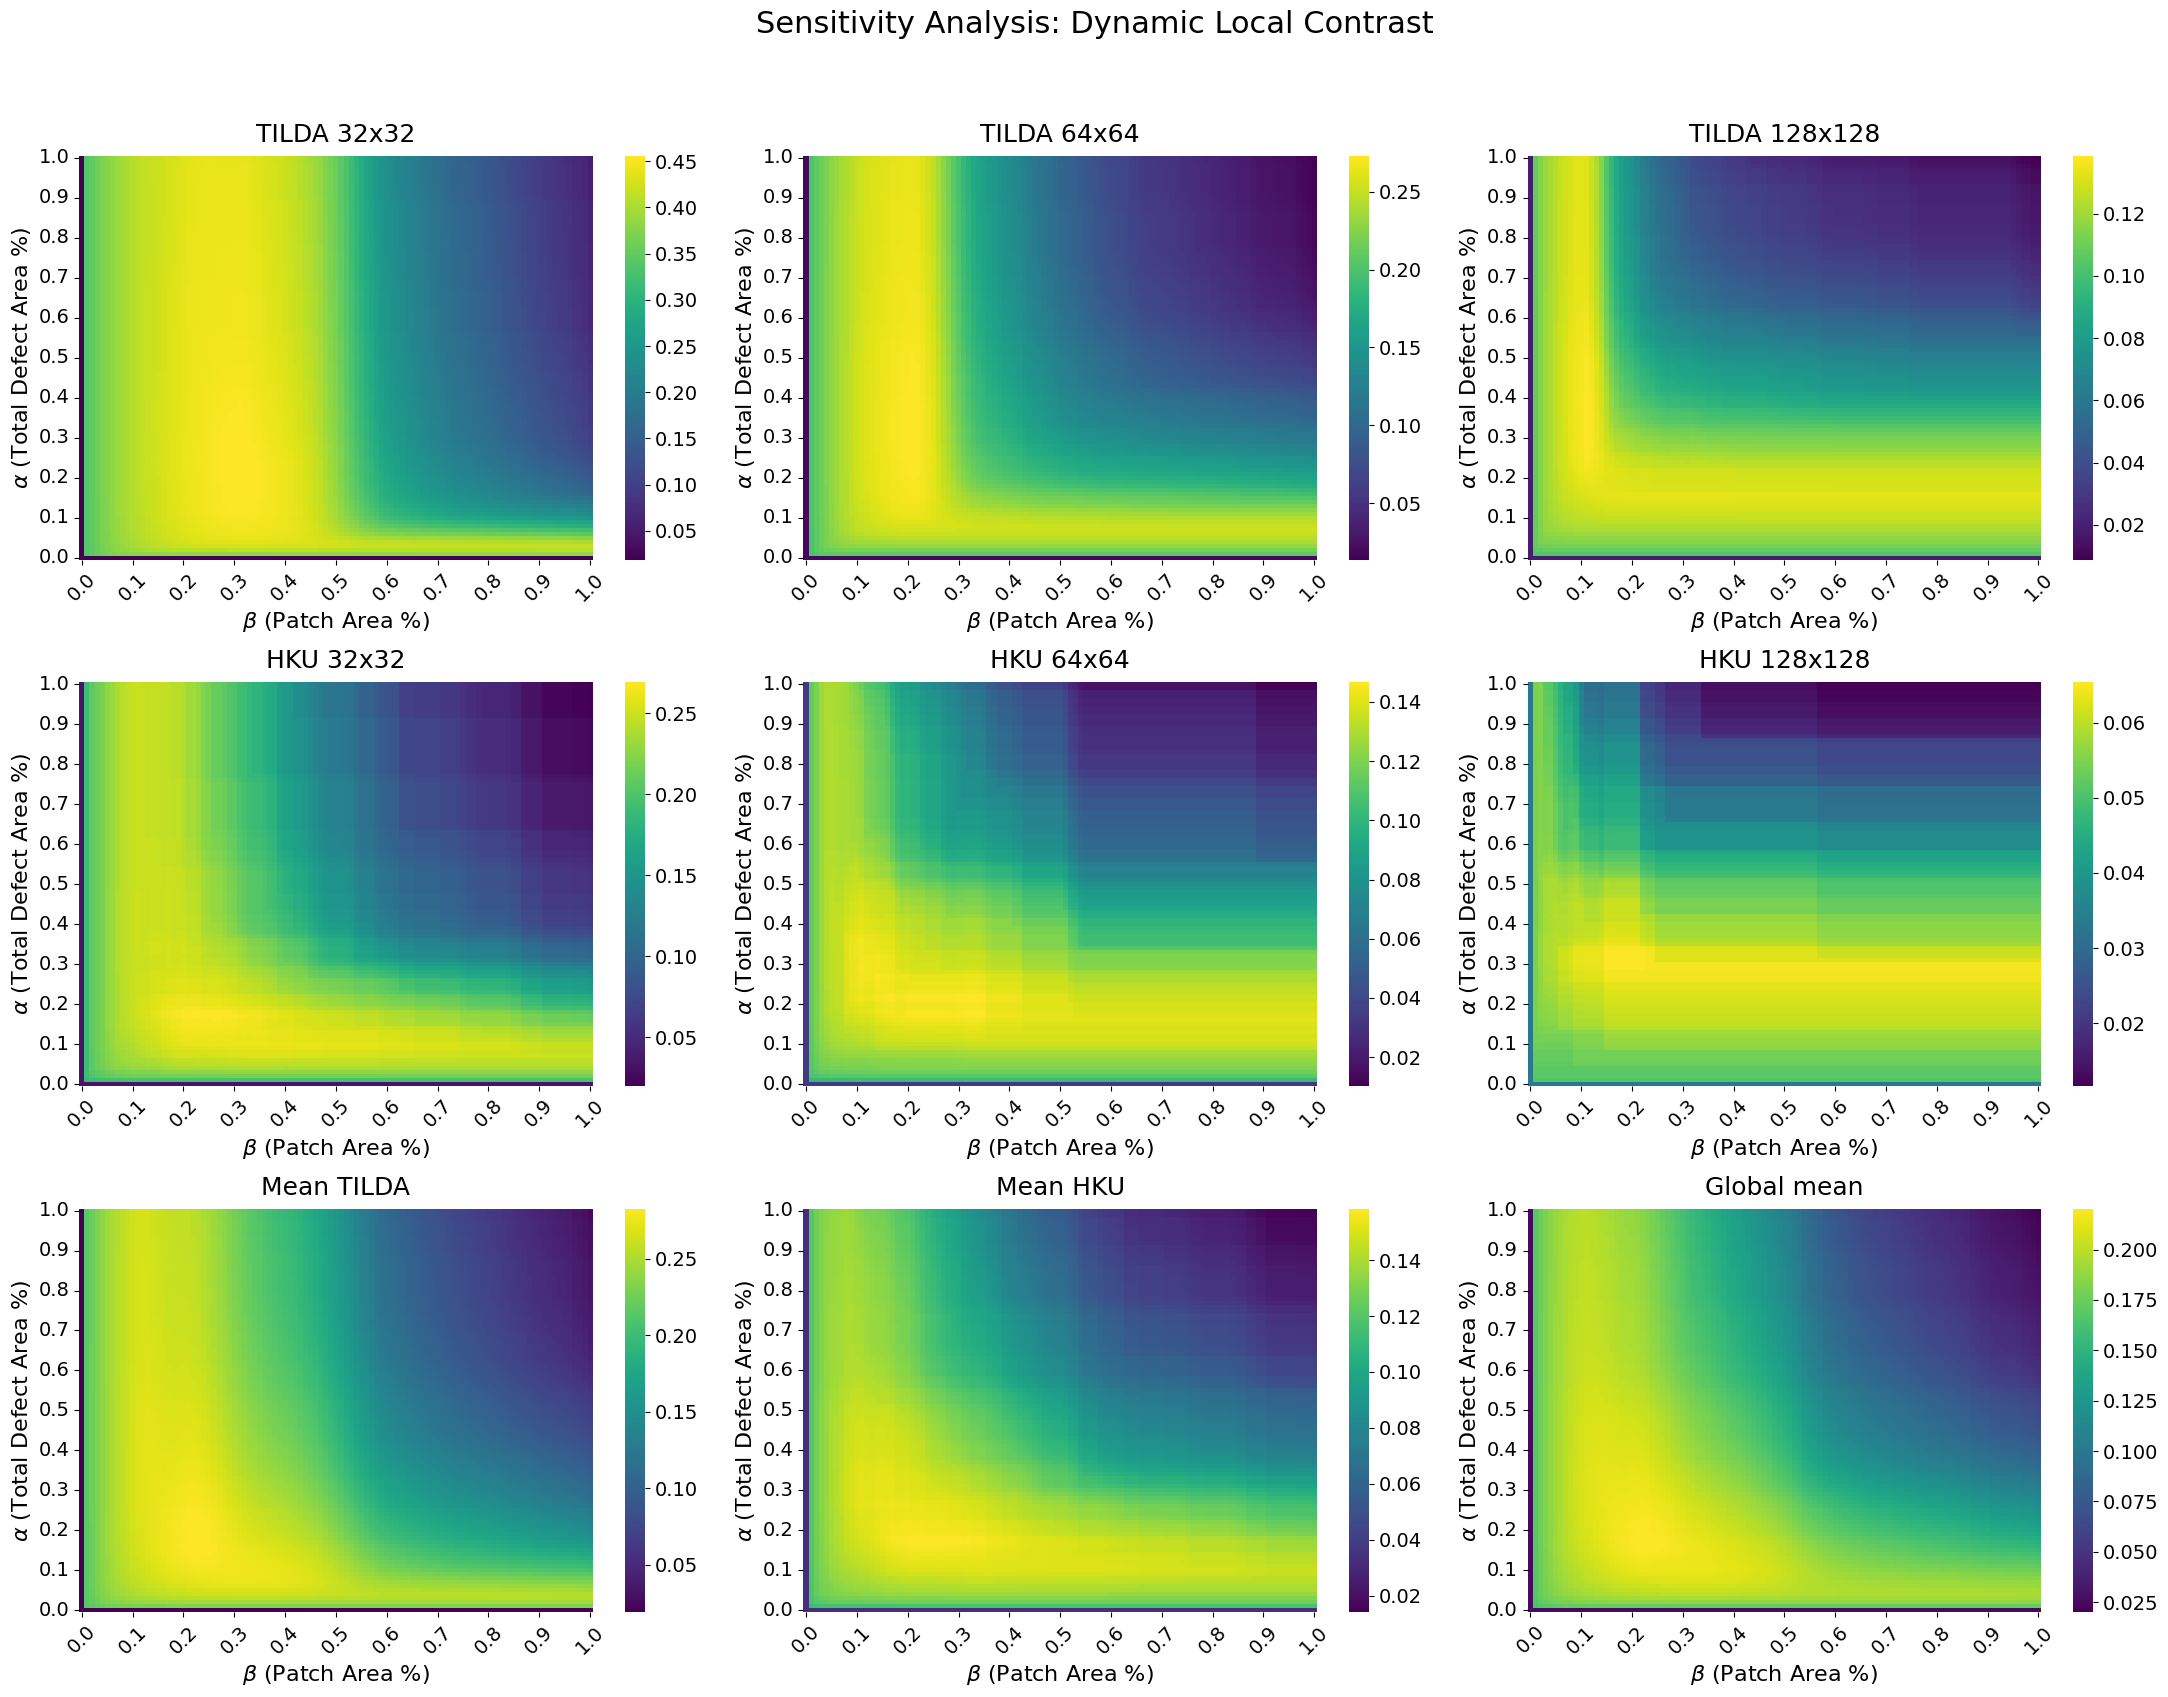

In [7]:
SHOW_ANNOTATIONS = False

fig, axes = plt.subplots(3, 3, figsize=(22, 18))
mode_str = "Dynamic Local Contrast" if DYNAMIC_RANGE else "Global Static Contrast"
fig.suptitle(f'Sensitivity Analysis: {mode_str}', fontsize=22, y=0.97)

for idx, (data, title) in enumerate(plot_list):
    row, col = idx // 3, idx % 3
    plot_custom_heatmap(axes[row, col], data, title)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.savefig('/kaggle/working/sensitivity_grid_dynamic.png', dpi=300)
plt.show()